# Generación, limpieza y transformación de un DataSet el principio GIGO

Fecha: 28 de mayo del 2026

Autor: Abiel Ontiveros Calvario

# Objetivo general
identificar problemas de calidad de datos,aplicar técnicas de limpieza y transformación,
y analizar cómo los datos incorrectos afectan el análisis y los modelos de Machine Learning mediante el principio GIGO.

# Actividad

Identifique y documente:

- Valores nulos
- Outliers (Negativos o fuera de rango)
- Datos inválidos
- Facturas canceladas ( identificadas con la letra c)
- Duplicados
- Problemas de formato o tipo de datos (Fechas o Monto)

Posteriormente:

- Limpie el dataset
- Transforme los datos
- Justifique las decisiones tomadas
- Explique cómo afecta el principio GIGO al análisis de datos y Machine Learning

# Graficas solicitadas para la identificación de anomalias
1. Ventas por pais
2. Heatmap de valores nulos
3. Distribución del monto

# Nota: 
Al terminar exportar el dataset limpio a formato csv y subir junto con el Laboratorio a GitHub, cumpliendo  con la siguiente estructura.

    - Notebooks (Folder)
        - Lab07.ipynb
    - DataSet (Folder)
        - Data_Limpio_Factura.csv

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [ ]:
df = pd.read_csv("../DataSet/ventas-por-factura.csv")

In [9]:
df.head()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33"
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73"
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95"
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83"


In [10]:
df.tail()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
25948,C556518,6/13/2021 10:53:00,16794.0,United Kingdom,-2,"-12,70"
25949,553060,5/13/2021 10:44:00,15826.0,United Kingdom,488,"720,00"
25950,577049,11/17/2021 13:58:00,17397.0,United Kingdom,104,"298,78"
25951,550122,4/14/2021 12:39:00,12931.0,United Kingdom,1176,"1488,00"
25952,537999,12/9/2020 11:44:00,NaN,United Kingdom,-223,"0,00"


In [11]:
# Mostrar información general del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25953 entries, 0 to 25952
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   N° de factura     25953 non-null  str    
 1   Fecha de factura  25953 non-null  str    
 2   ID Cliente        22229 non-null  float64
 3   País              25953 non-null  str    
 4   Cantidad          25953 non-null  int64  
 5   Monto             25953 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 1.2 MB


In [12]:
# Mostrar cantidad de filas y columnas
df.shape

(25953, 6)

In [13]:
# Mostrar estadísticas descriptivas
df.describe()


,ID Cliente,Cantidad
count,22229.000000,25953.000000
mean,15238.289892,199.474049
std,1732.981685,1107.075809
min,12346.000000,-80995.000000
25%,13755.000000,6.000000
50%,15136.000000,100.000000
75%,16746.000000,240.000000
max,18287.000000,80995.000000


In [14]:
# Contar valores nulos por columna
df.isnull().sum()

N° de factura          0
Fecha de factura       0
ID Cliente          3724
País                   0
Cantidad               0
Monto                  0
dtype: int64

In [15]:
# Calcular porcentaje de valores nulos
(df.isnull().sum() / len(df)) * 100

N° de factura        0.000000
Fecha de factura     0.000000
ID Cliente          14.349016
País                 0.000000
Cantidad             0.000000
Monto                0.000000
dtype: float64

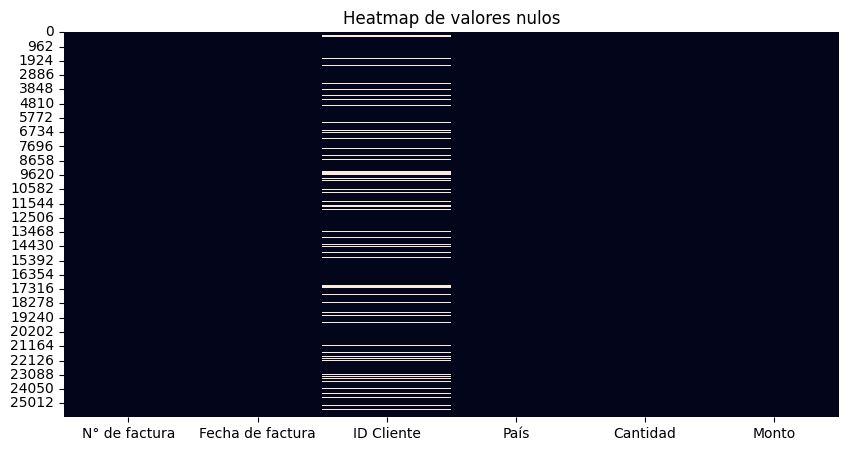

In [16]:
# Configurar tamaño de la gráfica
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Heatmap de valores nulos")
plt.show()

In [17]:
# Contar registros duplicados
df.duplicated().sum()

np.int64(10)

In [18]:
# Mostrar filas duplicadas
df[df.duplicated()]

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
7626,568403,9/27/2021 10:35:00,NaN,United Kingdom,-3,"0,00"
9728,C581390,12/8/2021 13:13:00,13081.0,United Kingdom,-13,"-15,85"
11263,568417,9/27/2021 11:10:00,14911.0,EIRE,202,"776,30"
12533,C581384,12/8/2021 13:06:00,17673.0,United Kingdom,-2,"-6,90"
13011,568423,9/27/2021 11:24:00,17061.0,United Kingdom,118,"573,40"
13054,568387,9/27/2021 10:04:00,13704.0,United Kingdom,340,"422,32"
15861,568384,9/27/2021 9:46:00,12748.0,United Kingdom,1,"0,00"
18795,C581323,12/8/2021 11:53:00,14442.0,Channel Islands,-1,"-4,25"
22578,C581330,12/8/2021 11:57:00,15877.0,United Kingdom,-125,"-52,50"
25704,568404,9/27/2021 10:36:00,NaN,United Kingdom,-17,"0,00"


In [19]:
# Eliminar registros duplicados
df = df.drop_duplicates()

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
# Buscar facturas que comienzan con la letra C
facturas_canceladas = df[df["N° de factura"].astype(str).str.startswith("C")]

In [22]:
# Contar facturas canceladas
facturas_canceladas.shape[0]

3837

In [23]:
# Eliminar registros cuya factura inicia con C
df = df[~df["N° de factura"].astype(str).str.startswith("C")]

In [24]:
# Mostrar cantidad de registros restantes
df.shape

(22106, 6)

In [25]:
# Reemplazar comas por puntos decimales
df["Monto"] = df["Monto"].astype(str).str.replace(",", ".", regex=False)

In [26]:
# Convertir columna a tipo float
df["Monto"] = pd.to_numeric(df["Monto"], errors="coerce")

In [27]:
df.info()

<class 'pandas.DataFrame'>
Index: 22106 entries, 0 to 25952
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   N° de factura     22106 non-null  str    
 1   Fecha de factura  22106 non-null  str    
 2   ID Cliente        18566 non-null  float64
 3   País              22106 non-null  str    
 4   Cantidad          22106 non-null  int64  
 5   Monto             22106 non-null  float64
dtypes: float64(2), int64(1), str(3)
memory usage: 1.2 MB


In [28]:
# Convertir la columna de fecha a formato datetime
df["Fecha de factura"] = pd.to_datetime(df["Fecha de factura"], errors="coerce")

In [29]:
df.info()

<class 'pandas.DataFrame'>
Index: 22106 entries, 0 to 25952
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   N° de factura     22106 non-null  str           
 1   Fecha de factura  22106 non-null  datetime64[us]
 2   ID Cliente        18566 non-null  float64       
 3   País              22106 non-null  str           
 4   Cantidad          22106 non-null  int64         
 5   Monto             22106 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 1.2 MB


In [30]:
# Contar fechas inválidas
df["Fecha de factura"].isnull().sum()

np.int64(0)

In [31]:
# Eliminar registros con fechas inválidas
df = df.dropna(subset=["Fecha de factura"])

In [32]:
# Mostrar registros con cantidades negativas
df[df["Cantidad"] < 0]

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
16,542418,2021-01-27 17:39:00,NaN,United Kingdom,-17,0.0
21,550759,2021-04-20 12:09:00,NaN,United Kingdom,-7,0.0
123,549142,2021-04-06 15:26:00,NaN,United Kingdom,-24,0.0
126,576674,2021-11-16 12:00:00,NaN,United Kingdom,-6,0.0
175,541967,2021-01-24 13:35:00,NaN,United Kingdom,-3,0.0
...,...,...,...,...,...,...
25783,537450,2020-12-07 09:26:00,NaN,United Kingdom,-19,0.0
25794,551575,2021-05-03 11:16:00,NaN,United Kingdom,-6,0.0
25818,567057,2021-09-16 11:39:00,NaN,United Kingdom,-8,0.0
25925,575617,2021-11-10 12:53:00,NaN,United Kingdom,-90,0.0


In [33]:
# Mostrar registros con montos negativos
df[df["Monto"] < 0]

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
5593,A563186,2021-08-12 14:51:00,NaN,United Kingdom,1,-11062.06
7569,A563187,2021-08-12 14:52:00,NaN,United Kingdom,1,-11062.06


In [34]:
# Mantener solo cantidades mayores a 0
df = df[df["Cantidad"] > 0]

In [35]:
# Mantener solo montos mayores a 0
df = df[df["Monto"] > 0]

In [36]:
df.shape

(20002, 6)

In [37]:
# Contar clientes nulos
df["ID Cliente"].isnull().sum()

np.int64(1440)

In [38]:
# Mostrar registros sin ID de cliente
df[df["ID Cliente"].isnull()]

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
11,539736,2020-12-21 15:18:00,NaN,United Kingdom,143,1172.46
12,537823,2020-12-08 14:25:00,NaN,United Kingdom,1484,6073.71
23,556427,2021-06-10 13:23:00,NaN,United Kingdom,92,435.69
28,562417,2021-08-04 16:32:00,NaN,United Kingdom,526,1691.38
41,549684,2021-04-11 13:24:00,NaN,United Kingdom,1,30.00
...,...,...,...,...,...,...
25909,555320,2021-06-02 11:00:00,NaN,United Kingdom,51,377.94
25917,559052,2021-07-05 16:53:00,NaN,United Kingdom,1562,4178.58
25930,539300,2020-12-16 17:31:00,NaN,United Kingdom,38,72.59
25932,565303,2021-09-02 12:17:00,NaN,Unspecified,258,286.85


In [39]:
# Eliminar registros sin ID Cliente
df = df.dropna(subset=["ID Cliente"])

In [40]:
# Verificar cambios
df["ID Cliente"].isnull().sum()

np.int64(0)

In [41]:
# Convertir IDs de cliente a enteros
df["ID Cliente"] = df["ID Cliente"].astype(int)

In [42]:
df.info()

<class 'pandas.DataFrame'>
Index: 18562 entries, 0 to 25951
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   N° de factura     18562 non-null  str           
 1   Fecha de factura  18562 non-null  datetime64[us]
 2   ID Cliente        18562 non-null  int64         
 3   País              18562 non-null  str           
 4   Cantidad          18562 non-null  int64         
 5   Monto             18562 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(2), str(2)
memory usage: 1015.1 KB


In [43]:
# Eliminar espacios y normalizar formato
df["País"] = df["País"].astype(str).str.strip().str.title()

In [44]:
df["País"].unique()

<StringArray>
[      'United Kingdom',              'Germany',                 'Eire',
               'France',               'Sweden',              'Belgium',
                'Italy',               'Israel',             'Portugal',
          'Netherlands',      'Channel Islands',          'Switzerland',
              'Finland',                'Spain',                'Japan',
 'United Arab Emirates',            'Singapore',               'Norway',
              'Denmark',            'Australia',                  'Usa',
            'Lithuania',   'European Community',              'Austria',
               'Cyprus',              'Iceland',          'Unspecified',
                'Malta',               'Canada',               'Greece',
               'Poland',       'Czech Republic',              'Lebanon',
               'Brazil',                  'Rsa',              'Bahrain',
         'Saudi Arabia']
Length: 37, dtype: str

In [45]:
# Extraer año
df["Año"] = df["Fecha de factura"].dt.year

# Extraer mes
df["Mes"] = df["Fecha de factura"].dt.month

# Extraer día
df["Día"] = df["Fecha de factura"].dt.day

# Extraer hora
df["Hora"] = df["Fecha de factura"].dt.hour

In [46]:
df.head()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto,Año,Mes,Día,Hora
0,548370,2021-03-30 16:14:00,15528,United Kingdom,123,229.33,2021,3,30,16
1,575767,2021-11-11 11:11:00,17348,United Kingdom,163,209.73,2021,11,11,11
3,549106,2021-04-06 12:08:00,17045,United Kingdom,1,39.95,2021,4,6,12
4,573112,2021-10-27 15:33:00,16416,United Kingdom,357,344.83,2021,10,27,15
5,576630,2021-11-16 08:38:00,13816,Germany,91,199.98,2021,11,16,8


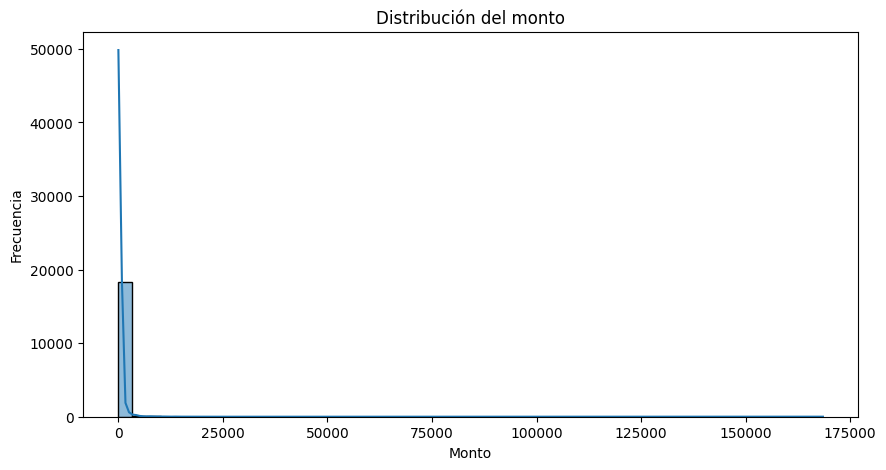

In [48]:
plt.figure(figsize=(10,5))
sns.histplot(df["Monto"], bins=50, kde=True)
plt.title("Distribución del monto")
plt.xlabel("Monto")
plt.ylabel("Frecuencia")
plt.show()

In [49]:
Q1 = df["Monto"].quantile(0.25)
Q3 = df["Monto"].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
outliers = df[
    (df["Monto"] < limite_inferior) |
    (df["Monto"] > limite_superior)
]
outliers.head()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto,Año,Mes,Día,Hora
27,576083,2021-11-14 08:22:00,17404,Sweden,1060,1238.48,2021,11,14,8
40,539049,2020-12-15 16:21:00,15615,United Kingdom,364,1048.64,2020,12,15,16
67,577783,2021-11-21 16:20:00,18139,United Kingdom,1644,2786.40,2021,11,21,16
95,569695,2021-10-05 15:35:00,16843,United Kingdom,938,993.88,2021,10,5,15
105,575854,2021-11-11 12:20:00,14125,United Kingdom,486,1111.08,2021,11,11,12


In [50]:
outliers.shape[0]

1468

In [51]:
# Filtrar dataset sin outliers extremos
df = df[
    (df["Monto"] >= limite_inferior) &
    (df["Monto"] <= limite_superior)
]

In [52]:
df.shape

(17094, 10)

In [53]:
ventas_pais = df.groupby("País")["Monto"].sum().sort_values(ascending=False)

In [54]:
ventas_pais.head(10)

País
United Kingdom    4640213.64
Germany            139668.05
France             128758.33
Eire                90598.57
Belgium             33824.05
Spain               24766.73
Portugal            18228.68
Switzerland         17661.67
Australia           16675.03
Finland             16417.67
Name: Monto, dtype: float64

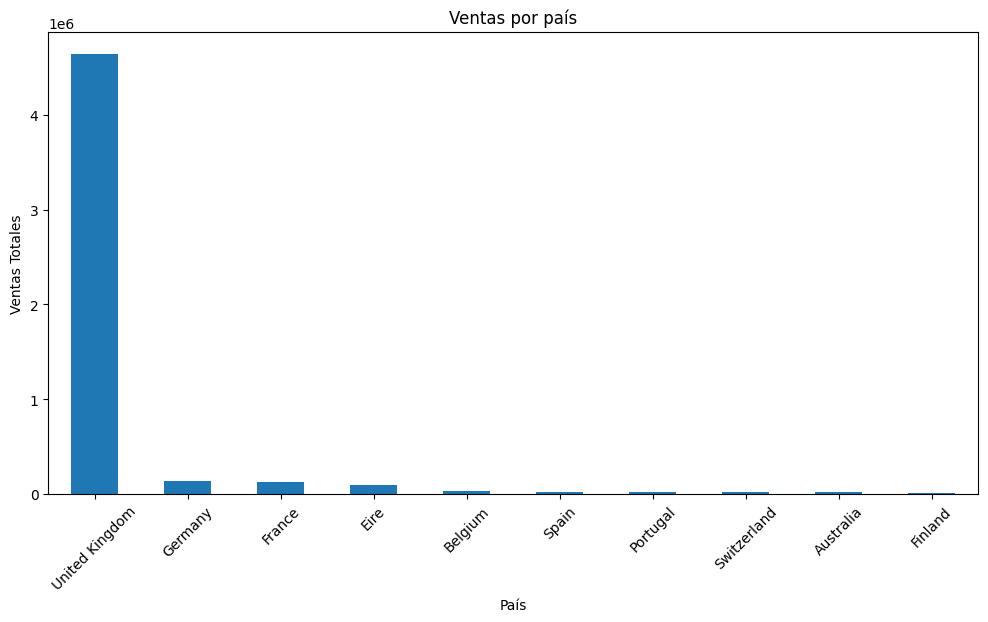

In [55]:
plt.figure(figsize=(12,6))
ventas_pais.head(10).plot(kind="bar")
plt.title("Ventas por país")
plt.xlabel("País")
plt.ylabel("Ventas Totales")
plt.xticks(rotation=45)
plt.show()

In [56]:
# Contar valores nulos finales
df.isnull().sum()

N° de factura       0
Fecha de factura    0
ID Cliente          0
País                0
Cantidad            0
Monto               0
Año                 0
Mes                 0
Día                 0
Hora                0
dtype: int64

In [57]:
# Verificar registros duplicados
df.duplicated().sum()

np.int64(0)

In [58]:
df.describe()

,Fecha de factura,ID Cliente,Cantidad,Monto,Año,Mes,Día,Hora
count,17094,17094.000000,17094.000000,17094.000000,17094.000000,17094.000000,17094.000000,17094.000000
mean,2021-07-01 00:16:40.189540,15288.065345,183.635077,305.222720,2020.924418,7.406517,14.965777,12.523634
min,2020-12-01 08:26:00,12347.000000,1.000000,0.380000,2020.000000,1.000000,1.000000,6.000000
25%,2021-03-30 12:37:00,13798.000000,69.000000,148.780000,2021.000000,5.000000,7.000000,11.000000
50%,2021-07-10 13:49:00,15203.000000,141.000000,282.185000,2021.000000,8.000000,15.000000,12.000000
75%,2021-10-12 13:30:45,16794.000000,249.000000,408.795000,2021.000000,11.000000,22.000000,14.000000
max,2021-12-09 12:50:00,18287.000000,3186.000000,940.800000,2021.000000,12.000000,31.000000,20.000000
std,NaN,1728.099261,171.933917,203.189813,0.264336,3.442434,8.679674,2.371805


In [59]:
# Exportar dataset limpio a CSV
df.to_csv("../DataSet/Data_Limpio_Factura.csv", index=False)

In [60]:
# Mensaje de confirmación
print("Dataset limpio exportado correctamente")

Dataset limpio exportado correctamente
